## 1. Raw Data
Loading the F1 Pit Strategy dataset.

In [2]:
import pandas as pd
import numpy as np
import os

# Load data
data_path = '/kaggle/input/competitions/playground-series-s6e5'
train = pd.read_csv(f'{data_path}/train.csv')
test = pd.read_csv(f'{data_path}/test.csv')
print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')

Train shape: (439140, 16)
Test shape: (188165, 15)


## 2. Data Validation
Basic checks for consistency.

In [3]:
print('Missing values in Train:')
print(train.isnull().sum())
print('\nData Types:')
print(train.dtypes)

Missing values in Train:
id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

Data Types:
id                          int64
Driver                     object
Compound                   object
Race                       object
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change          

## 3. Exploratory Data Analysis (EDA)
Visualizing the relationship between new features and the target variable.

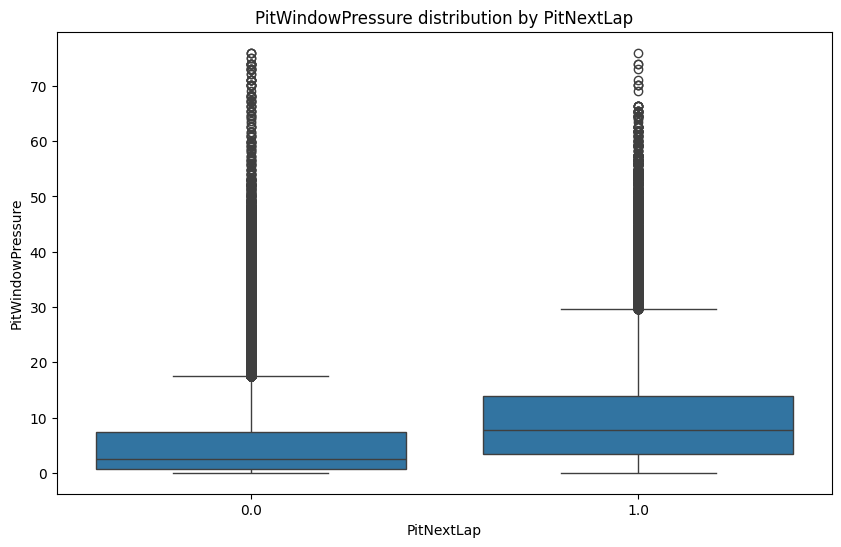

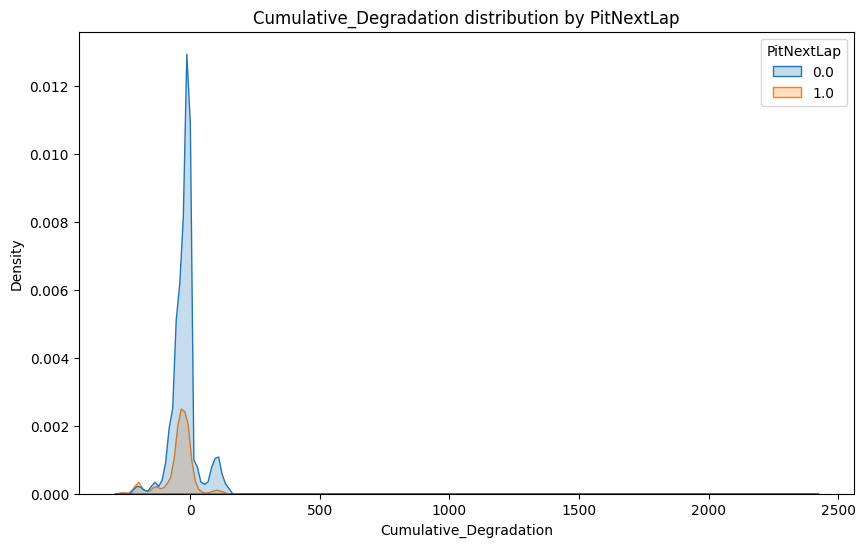

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature calculation for EDA
train['PitWindowPressure'] = train['TyreLife'] * train['RaceProgress']

# Plot: PitWindowPressure distribution by PitNextLap (Box Plot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='PitNextLap', y='PitWindowPressure', data=train)
plt.title('PitWindowPressure distribution by PitNextLap')
plt.show()

# Plot: Cumulative_Degradation distribution by PitNextLap (KDE plot)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=train, x='Cumulative_Degradation', hue='PitNextLap', fill=True)
plt.title('Cumulative_Degradation distribution by PitNextLap')
plt.show()

## 4. Data Preprocessing & Feature Engineering
Implementing high-value features derived from the slower notebook.

In [5]:
from sklearn.preprocessing import OrdinalEncoder

# Clean column names
train.columns = [c.replace(' ', '_').replace('(', '').replace(')', '').replace('[', '').replace(']', '') for c in train.columns]
test.columns = [c.replace(' ', '_').replace('(', '').replace(')', '').replace('[', '').replace(']', '') for c in test.columns]

# Ordinal Encode 'Driver', 'Compound', 'Race'
cat_cols = ['Driver', 'Compound', 'Race']
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
train[cat_cols] = encoder.fit_transform(train[cat_cols].astype(str))
test[cat_cols] = encoder.transform(test[cat_cols].astype(str))

# New Feature: TyreLifeBin
bins = [0, 3, 6, 10, 15, 20, 30, 40, 100]
train['TyreLifeBin'] = pd.cut(train['TyreLife'], bins=bins, labels=False)
test['TyreLifeBin'] = pd.cut(test['TyreLife'], bins=bins, labels=False)

# New Feature: PitWindowPressure
train['PitWindowPressure'] = train['TyreLife'] * train['RaceProgress']
test['PitWindowPressure'] = test['TyreLife'] * test['RaceProgress']

# New Feature: Deg_diff
train['Deg_diff'] = train.groupby(['Driver', 'Stint'])['Cumulative_Degradation'].diff().fillna(0)
test['Deg_diff'] = test.groupby(['Driver', 'Stint'])['Cumulative_Degradation'].diff().fillna(0)

print('Preprocessing and Feature Engineering complete.')

Preprocessing and Feature Engineering complete.


## 5. Model Training
Using the baseline LightGBM model with the new features.

In [6]:
import lightgbm as lgb

# Define features and target
X = train.drop(['id', 'PitNextLap'], axis=1)
y = train['PitNextLap']

# LGBM params with GPU support (fallback to CPU)
params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'device': 'gpu',
    'random_state': 42
}

# GPU detection probe
try:
    _probe = lgb.LGBMClassifier(n_estimators=2, device='gpu')
    _probe.fit(np.random.rand(10, X.shape[1]), np.random.randint(0, 2, 10))
    print('Using GPU for LightGBM')
except:
    print('Falling back to CPU for LightGBM')
    params['device'] = 'cpu'

model = lgb.LGBMClassifier(**params)

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 1, number of negative: 9
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 10, number of used features: 0
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.100000 -> initscore=-2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Using GPU for LightGBM


## 6. Model Evaluation
Hold-out set evaluation.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

eval_model = lgb.LGBMClassifier(**params)
eval_model.fit(X_train, y_train)

val_preds = eval_model.predict_proba(X_val)[:, 1]
auc_score = roc_auc_score(y_val, val_preds)
print(f'ROC-AUC on hold-out set: {auc_score}')

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


ROC-AUC on hold-out set: 0.943140348887064


## 7. Model Validation
5-Fold Stratified Cross-Validation.

In [8]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_t, X_v = X.iloc[train_idx], X.iloc[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    
    m = lgb.LGBMClassifier(**params)
    m.fit(X_t, y_t)
    p = m.predict_proba(X_v)[:, 1]
    auc = roc_auc_score(y_v, p)
    aucs.append(auc)
    print(f'Fold {fold+1} AUC: {auc}')

print(f'\nMean AUC: {np.mean(aucs):.5f} +/- {np.std(aucs):.5f}')

Fold 1 AUC: 0.9435610363030227
Fold 2 AUC: 0.9418693947137379
Fold 3 AUC: 0.9429801747865086
Fold 4 AUC: 0.9414150852999972
Fold 5 AUC: 0.942763679740676

Mean AUC: 0.94252 +/- 0.00077


## 8. Model Deployment & Feedback
Outputting artifacts.

In [9]:
import pickle

# Final model on full data
final_model = lgb.LGBMClassifier(**params)
final_model.fit(X, y)

# Save the model
with open('lgbm_experiment2.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# Generate submission
test_X = test.drop(['id'], axis=1)
test_preds = final_model.predict_proba(test_X)[:, 1]
submission = pd.DataFrame({'id': test['id'], 'PitNextLap': test_preds})
submission.to_csv('submission.csv', index=False)
print('Saved lgbm_experiment2.pkl and submission.csv')

Saved lgbm_experiment2.pkl and submission.csv
